In [2]:
import pandas as pd
import ast
import argparse
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import math


In [3]:
PRECLINICAL_METADATA_PATH = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/03_IE_ner/data/animal_studies_with_drug_disease/animal_studies_metadata_595768.csv"
PRECLINICAL_ANNOTATIONS_PATH = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/mapped_preclinical_data_enriched.csv"

# load data
metadata_df = pd.read_csv(PRECLINICAL_METADATA_PATH)
annotations_df = pd.read_csv(PRECLINICAL_ANNOTATIONS_PATH)[['PMID', 
       'linkbert_mapped_conditions', 'linkbert_mapped_drugs',
       'disease_term_mondo_norm', 'disease_mondo_termid',
       'drug_term_umls_norm', 'drug_umls_termid']]

print(f"Initial shapes -> metadata: {metadata_df.shape}, annotations: {annotations_df.shape}")

# deduplicate both by PMID
annotations_df = annotations_df.drop_duplicates(subset=["PMID"])
print(f"After dedup annotations: {annotations_df.shape}")

metadata_df = metadata_df.drop_duplicates(subset=["PMID"])
print(f"After dedup metadata: {metadata_df.shape}")

# merge on PMID (left join to keep all annotation records)
merged_matadata_df = pd.merge(annotations_df, metadata_df, on="PMID", how="left")
print(f"After merge: {merged_matadata_df.shape}")

# check unique PMIDs
print(f"Unique PMIDs after merge: {merged_matadata_df['PMID'].nunique()}")


Initial shapes -> metadata: (595768, 7), annotations: (547365, 7)
After dedup annotations: (547365, 7)
After dedup metadata: (581385, 7)
After merge: (547365, 13)
Unique PMIDs after merge: 547365


In [4]:
merged_matadata_df[merged_matadata_df['PMID']==2434820]

,PMID,linkbert_mapped_conditions,linkbert_mapped_drugs,disease_term_mondo_norm,disease_mondo_termid,drug_term_umls_norm,drug_umls_termid,unique_conditions_linkbert_predictions,unique_interventions_linkbert_predictions,year,journal_name,publication_type,title
547361,2434820,parkinson disease,ethanol|acetaldehyde,Parkinson disease,MONDO:0005180,Ethanol|Acetaldehyde,C0001962|C0000966,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
merged_matadata_df[merged_matadata_df["unique_interventions_linkbert_predictions"].astype(str).str.contains("fampridine", case=False, na=False)]


,PMID,linkbert_mapped_conditions,linkbert_mapped_drugs,disease_term_mondo_norm,disease_mondo_termid,drug_term_umls_norm,drug_umls_termid,unique_conditions_linkbert_predictions,unique_interventions_linkbert_predictions,year,journal_name,publication_type,title
107151,26101174,lambert-eaton myasthenic syndrome,"3 , 4-diaminopyridine|amifampridine|amifamprid...",Lambert-Eaton myasthenic syndrome,MONDO:0018556,"2,4-diaminopyridine|AMIFAMPRIDINE|Amifampridin...",C0045476|C0046948|C2917064|C0046948,lambert-eaton myasthenic syndrome,amifampridine phosphate salt|amifampridine|ami...,2015.0,Clinical therapeutics,Journal Article+Randomized Controlled Trial+Re...,Effects of Food Intake on the Relative Bioavai...
155117,22560931,multiple sclerosis,non-specific kv channel blocker|dalfampridine|...,multiple sclerosis,MONDO:0005301,non-specific kv channel blocker|Dalfampridine|...,-1|C0000477|C0000477|C0002584,multiple sclerosis,dalfampridine|non-specific kv channel blocker|...,2012.0,Neurobiology of disease,"Journal Article+Research Support, N.I.H., Extr...",K+ channel alterations in the progression of e...
183497,37567585,multiple sclerosis,dalfampridine|dalfampridine,multiple sclerosis,MONDO:0005301,Dalfampridine|Dalfampridine,C0000477|C0000477,multiple sclerosis,fampridine|dalfampridine,2024.0,Journal of chromatographic science,Journal Article,Ultra-High Performance Liquid Chromatography M...
243334,37242713,lambert-eaton myasthenic syndrome,amifampridine|n-acetyltransferase 2|acetaminophen,Lambert-Eaton myasthenic syndrome,MONDO:0018556,AMIFAMPRIDINE|N-acetyltransferase-1|Acetaminophen,C0046948|C0259190|C0000970,lambert-eaton myasthenic syndrome,acetaminophen|amifampridine|n-acetyltransferase 2,2023.0,Pharmaceutics,Journal Article,Investigation of N-Acetyltransferase 2-Mediate...
244407,21501202,lambert-eaton myasthenic syndrome,", 4-dap|3 , 4-diaminopyridine|amifampridine|3 ...",Lambert-Eaton myasthenic syndrome,MONDO:0018556,", 4-dap|2,4-diaminopyridine|AMIFAMPRIDINE|3 , ...",-1|C0045476|C0046948|-1,lambert-eaton myasthenic syndrome,", 4-dap|3 , 4-dap|amifampridine|3 , 4-diaminop...",2012.0,Journal of clinical pharmacy and therapeutics,"Journal Article+Research Support, Non-U.S. Gov't",Content variability of active drug substance i...
311081,33738893,multiple sclerosis,[15]n] dalfampridine|[[15] n] dalfampridine,multiple sclerosis,MONDO:0005301,[15]n] dalfampridine|[[15] n] dalfampridine,-1|-1,multiple sclerosis,[15]n] dalfampridine|[[15] n] dalfampridine,2021.0,Chemphyschem : a European journal of chemical ...,"Journal Article+Research Support, Non-U.S. Gov't",Synthesis and [15] N NMR Signal Amplification ...
332946,23652269,stroke,potassium channel blocker|dalfampridine,stroke disorder,MONDO:0005098,potassium channel blocker|Dalfampridine,-1|C0000477,stroke,dalfampridine|potassium channel blocker,2013.0,Stroke,Journal Article+Randomized Controlled Trial,Dalfampridine improves sensorimotor function i...
383793,38934397,spinal cord injuries|spinal cord injuries|chro...,intracellular sigma peptide|acteoside|granuloc...,spinal cord injury|chronic spinal cord injury,MONDO:0043797|-1,intracellular sigma peptide|acteoside|Granuloc...,-1|C0101334|C0079459|C0012497|-1|-1|C0065751|-...,| spinal cord injury|chronic spinal cord injur...,diosgenin|chondroitinase abc|granulocyte-colon...,2025.0,Neural regeneration research,Journal Article,Pharmacological intervention for chronic phase...


In [30]:
def build_annotation_files(base_dir):
    return {
        'animal_sex': (
            os.path.join(base_dir, "regex/sex_doc_level_predictions.csv"),
            {'prediction_encoded_label': 'animal_sex'},
            False
        ),
        'animal_species': (
            os.path.join(base_dir, "regex/species_doc_level_predictions.csv"),
            {'prediction_encoded_label': 'animal_species'},
            False
        ),
        'animal_age': (
            os.path.join(base_dir, "age/age_unsloth_meta_llama_3.1_8b_doc_level_predictions_mapped.csv"),
            {
                'age_classification': 'animal_age_class',
                'prediction_normalized_age': 'animal_age'
            },
            False
        ),
        'rigor_blinding': (
            os.path.join(base_dir, "regex/blinding_doc_level_predictions.csv"),
            {'prediction_encoded_label': 'rigor_blinding'},
            False
        ),
        'rigor_randomization': (
            os.path.join(base_dir, "regex/randomization_doc_level_predictions.csv"),
            {'prediction_encoded_label': 'rigor_randomization'},
            False
        ),
        'rigor_welfare': (
            os.path.join(base_dir, "regex/welfare_doc_level_predictions.csv"),
            {'prediction_encoded_label': 'rigor_welfare'},
            False
        ),
        'assay_type': (
            os.path.join(base_dir, "regex/assay_doc_level_predictions.csv"),
            {'prediction_encoded_label': 'assay_type'},
            False
        ),
        'animal_strain': (
            os.path.join(base_dir, "strain/strain_predictions_normalized.csv"),
            {'animal_strain_norm_family': 'animal_strain'},
            False
        ),
        'animal_number': (
            os.path.join(base_dir, "animals_nr/animals_nr_predictions_numeric.csv"),
            {'prediction_encoded_label': 'animal_number'},
            False
        ),
        'sample_size': (
            os.path.join(base_dir, "regex/sample_size_doc_level_predictions.csv"),
            {'prediction_encoded_label': 'sample_size'},
            False
        )
        ,
        'first_author_affiliation': (
            os.path.join(base_dir, "author_affiliations_pubmed_mapped.csv"),
            {'first_author_country': 'first_author_country'},
            False
        )
    }

def load_annotation(file_path, col_rename_map, parse_list=False):
    """
    Load a single annotation CSV file and select/rename columns as needed.

    Args:
        file_path (str): Path to the CSV file containing predictions.
        col_rename_map (dict): Mapping from column names in the file to desired output names.
        parse_list (bool): Whether to parse stringified lists into actual strings (e.g. ['a', 'b'] → 'a, b').

    Returns:
        pd.DataFrame: DataFrame with 'PMID' and renamed annotation columns.
    """
    print(f'Loading annotation from: {file_path}')
    df = pd.read_csv(file_path, low_memory=False)

    # Select only required columns
    required_cols = ['PMID'] + list(col_rename_map.keys())
    if missing := (set(required_cols) - set(df.columns)):
        raise ValueError(f"Missing columns in {file_path}: {missing}")
    
    df = df[required_cols].rename(columns=col_rename_map)

    # Optionally convert stringified lists to comma-separated strings
    if parse_list:
        for col in col_rename_map.values():
            df[col] = df[col].apply(
                lambda x: ', '.join(ast.literal_eval(x)) if pd.notna(x) else x
            )

    return df

In [31]:
base_annotation_dir = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/08_IE_full_text/model_predictions"
ANNOTATION_FILES = build_annotation_files(base_annotation_dir)

merged_annotations_df = None  # start empty

for label_group, (file_path, col_rename_map, parse_list) in ANNOTATION_FILES.items():
    print(f"\nProcessing annotation group: {label_group}")
    
    # load one annotation file
    annot_df = load_annotation(file_path, col_rename_map, parse_list=parse_list)
    print(f"Annotations size: {annot_df.shape}")
    
    # drop duplicates (if any)
    annot_df = annot_df.drop_duplicates(subset=["PMID"])
    annot_df["PMID"] = annot_df["PMID"].astype(str)
    print(f"After dedup: {annot_df.shape}")
    
    # merge into cumulative dataframe
    if merged_annotations_df is None:
        merged_annotations_df = annot_df
    else:
        merged_annotations_df = pd.merge(merged_annotations_df, annot_df, on="PMID", how="left")
    
    print(f"Current merged size: {merged_annotations_df.shape}")

# fill missing values after all merges
merged_annotations_df = merged_annotations_df.fillna("not reported")


Processing annotation group: animal_sex
Loading annotation from: /shares/animalwelfare.crs.uzh/Preclinical_Pipeline/08_IE_full_text/model_predictions/regex/sex_doc_level_predictions.csv
Annotations size: (340384, 2)
After dedup: (340380, 2)
Current merged size: (340380, 2)

Processing annotation group: animal_species
Loading annotation from: /shares/animalwelfare.crs.uzh/Preclinical_Pipeline/08_IE_full_text/model_predictions/regex/species_doc_level_predictions.csv
Annotations size: (340384, 2)
After dedup: (340380, 2)
Current merged size: (340380, 3)

Processing annotation group: animal_age
Loading annotation from: /shares/animalwelfare.crs.uzh/Preclinical_Pipeline/08_IE_full_text/model_predictions/age/age_unsloth_meta_llama_3.1_8b_doc_level_predictions_mapped.csv
Annotations size: (154741, 3)
After dedup: (154740, 3)
Current merged size: (340380, 5)

Processing annotation group: rigor_blinding
Loading annotation from: /shares/animalwelfare.crs.uzh/Preclinical_Pipeline/08_IE_full_text

In [36]:
merged_annotations_df[merged_annotations_df['PMID']=="2434820"]

,PMID,animal_sex,animal_species,animal_age_class,animal_age,rigor_blinding,rigor_randomization,rigor_welfare,assay_type,animal_strain,animal_number,sample_size,first_author_country


In [15]:
country_df = pd.read_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/08_IE_full_text/model_predictions/author_affiliations_pubmed_mapped.csv")
country_df

,PMID,first_author_affiliation,authors,all_affiliations,first_author_geolocation,first_author_country
0,10063484,"Institute of Pharmacology, Polish Academy of S...","Mamczarz J, Budziszewska B, Antkiewicz-Michalu...","Institute of Pharmacology, Polish Academy of S...","Krakow, Poland",Poland
1,10068158,"Department of Pharmacology, University of Ariz...","Ossipov M H, Bian D, Malan T P, Lai J, Porreca F","Department of Pharmacology, University of Ariz...","Tucson, AZ, USA",USA
2,10068163,"The University of Iowa, College of Medicine, D...","Sengupta J N, Snider A, Su X, Gebhart G F","The University of Iowa, College of Medicine, D...","Iowa City, IA, USA",USA
3,10068171,"Pain and Neurosensory Mechanisms Branch, Natio...","Eliav E, Herzberg U, Caudle R M","Pain and Neurosensory Mechanisms Branch, Natio...","Bethesda, MD, USA",USA
4,10068174,"The Institute of Biomedicine, Department of Ph...","Idänpään-Heikkilä J J, Guilbaud G","The Institute of Biomedicine, Department of Ph...","Helsinki, Finland",Finland
...,...,...,...,...,...,...
340284,20687175,"Laboratory of Epidemiology, Demography and Bio...","Shahar Avner, Patel Kushang V, Semba Richard D...","Laboratory of Epidemiology, Demography and Bio...","Bethesda, MD, USA",USA
340285,21801587,Department of Anesthesiology and Critical Care...,"Armstead William M, Raghupathi Ramesh",Department of Anesthesiology and Critical Care...,"Philadelphia, PA, USA",USA
340286,25188549,"Anaesthetics, Pain Medicine and Intensive Care...","Campos-Pires Rita, Armstrong Scott P, Sebastia...","Anaesthetics, Pain Medicine and Intensive Care...","London, UK",UK
340287,30673266,NaN,"Dong Xinyue, Gao Jin, Zhang Can Yang, Hayworth...",NaN,unlabeled,unlabeled


In [16]:
merged_annotations_df.head()

,PMID,animal_sex,animal_species,animal_age_class,animal_age,rigor_blinding,rigor_randomization,rigor_welfare,assay_type,animal_strain,animal_number,sample_size,first_author_country
0,157,sex-male,rat,not reported,not reported,blinding-not-reported,randomization-not-reported,welfare-not-reported,Histology,Sprague-Dawley,not reported,sample-size-not-reported,unlabeled
1,2163,sex-both,monkey,different species,2.2-6.5 years,blinding-not-reported,randomization-not-reported,welfare-not-reported,"Behavioral, Molecular & Cellular",Sprague-Dawley,not reported,sample-size-not-reported,unlabeled
2,2617,sex-not-reported,rabbit,not reported,not reported,blinding-not-reported,randomization-not-reported,welfare-not-reported,Molecular & Cellular,not reported,not reported,sample-size-not-reported,unlabeled
3,2891,sex-not-reported,rat,not reported,not reported,blinding-not-reported,randomization-not-reported,welfare-present,not reported,not reported,2.0,sample-size-not-reported,unlabeled
4,3420,sex-male,"cat, dog",not reported,not reported,blinding-not-reported,randomization-not-reported,welfare-not-reported,"Molecular & Cellular, Physiology",Mongrel,not reported,sample-size-not-reported,unlabeled


In [17]:
merged_annotations_df.shape

(340380, 13)

In [18]:
merged_annotations_df["PMID"] = merged_annotations_df["PMID"].astype(str)
merged_matadata_df["PMID"] = merged_matadata_df["PMID"].astype(str)

# Merge on PMID
dataset_fulltext = pd.merge(merged_annotations_df, merged_matadata_df, on="PMID", how="left")
dataset_fulltext.shape

(340380, 25)

In [19]:
dataset_fulltext

,PMID,animal_sex,animal_species,animal_age_class,animal_age,rigor_blinding,rigor_randomization,rigor_welfare,assay_type,animal_strain,...,disease_term_mondo_norm,disease_mondo_termid,drug_term_umls_norm,drug_umls_termid,unique_conditions_linkbert_predictions,unique_interventions_linkbert_predictions,year,journal_name,publication_type,title
0,157,sex-male,rat,not reported,not reported,blinding-not-reported,randomization-not-reported,welfare-not-reported,Histology,Sprague-Dawley,...,ischemic disease,MONDO:0005053,Lactate,C0376261,ischemic,lactate,1975.0,Circulation research,"Journal Article+Research Support, U.S. Gov't, ...",Mechanisms of glycolytic inhibition in ischemi...
1,2163,sex-both,monkey,different species,2.2-6.5 years,blinding-not-reported,randomization-not-reported,welfare-not-reported,"Behavioral, Molecular & Cellular",Sprague-Dawley,...,metabolic acidosis|poisoning,MONDO:0000440|MONDO:0029000,Fomepizole,C0048504,metabolic acidosis|poisoning,4-methylpyrazole,1975.0,Biochemical medicine,"Journal Article+Research Support, U.S. Gov't, ...",Methanol poisoning. I. The role of formic acid...
2,2617,sex-not-reported,rabbit,not reported,not reported,blinding-not-reported,randomization-not-reported,welfare-not-reported,Molecular & Cellular,not reported,...,hypochromic anemia,MONDO:0001357,Ethanol,C0001962,hypochromic anemias,ethanol,1976.0,The Journal of clinical investigation,"Journal Article+Research Support, U.S. Gov't, ...",A rabbit reticulocyte model for the role of he...
3,2891,sex-not-reported,rat,not reported,not reported,blinding-not-reported,randomization-not-reported,welfare-present,not reported,not reported,...,epilepsy,MONDO:0005027,Phenytoin|Pentobarbital,C0031507|C0030883,seizures,phenytoin|pentobarbital,1976.0,Neurology,Comparative Study+Journal Article+Research Sup...,Mechanism of action of anticonvulsants. Role o...
4,3420,sex-male,"cat, dog",not reported,not reported,blinding-not-reported,randomization-not-reported,welfare-not-reported,"Molecular & Cellular, Physiology",Mongrel,...,ventricular arrhythmias due to cardiac ryanodi...,MONDO:0020745|MONDO:0000190,beta-adrenergic receptor blocking agent|Nadolo...,-1|C0027302|-1|C0033497,cardiac arrhythmias|ventricular fibrillation,"propranolol|2 , 3-cis-1 , 2 , 3 , 4-tetrahydro...",1976.0,European journal of pharmacology,Journal Article,"Anti-arrhythmic action of nadolol, a beta-adre..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
340375,38129421,sex-female,mouse,not reported,not reported,blinding-not-reported,randomization-present,welfare-present,"Histology, Molecular & Cellular",C57BL/6,...,perinatal necrotizing enterocolitis,MONDO:0004639,mdanp,-1,necrotizing enterocolitis,mdanp,2023.0,Scientific reports,Journal Article,Active polypeptide MDANP protect against necro...
340376,38129863,sex-male,"mouse, rat",not reported,not reported,blinding-not-reported,randomization-not-reported,welfare-present,"Histology, Molecular & Cellular",C57BL/6,...,diabetes mellitus|obsolete diabetic angiopathy...,MONDO:0005015|MONDO:0006725|-1|-1|-1|-1,c-176|vadimezan,-1|C2930490,diabetes|endothelial dysfunction|diabetes-indu...,dmxaa|c-176,2023.0,Cell communication and signaling : CCS,Video-Audio Media+Journal Article+Research Sup...,Hyperglycemia-induced STING signaling activati...
340377,38129872,sex-male,rat,adult,adult,blinding-not-reported,randomization-not-reported,welfare-present,Molecular & Cellular,Wistar,...,diabetes mellitus|cognitive disorder,MONDO:0005015|MONDO:0002039,Quercetin,C0034392,cognitive impairment|diabetes,quercetin,2023.0,BMC pharmacology & toxicology,"Journal Article+Research Support, Non-U.S. Gov't","In diabetic male Wistar rats, quercetin-conjug..."
340378,38129888,sex-male,rat,not reported,not reported,blinding-present,randomization-present,welfare-present,Molecular & Cellular,Wistar,...,acute kidney failure,MONDO:0002492,Amlodipine,C0051696,acute kidney injury,amlodipine,2023.0,BMC pharmacology & toxicology,"J

In [20]:
dataset_fulltext.columns

Index(['PMID', 'animal_sex', 'animal_species', 'animal_age_class',
       'animal_age', 'rigor_blinding', 'rigor_randomization', 'rigor_welfare',
       'assay_type', 'animal_strain', 'animal_number', 'sample_size',
       'first_author_country', 'linkbert_mapped_conditions',
       'linkbert_mapped_drugs', 'disease_term_mondo_norm',
       'disease_mondo_termid', 'drug_term_umls_norm', 'drug_umls_termid',
       'unique_conditions_linkbert_predictions',
       'unique_interventions_linkbert_predictions', 'year', 'journal_name',
       'publication_type', 'title'],
      dtype='object')

In [25]:
dataset_fulltext[dataset_fulltext['PMID']=="26114502"]["disease_term_mondo_norm"]

155973    neuronitis|multiple sclerosis
Name: disease_term_mondo_norm, dtype: object

In [21]:
dataset_fulltext.to_csv(f"{base_annotation_dir}/full_text_combined_all_annotations.csv",index=False)

## Viz

In [276]:
colorblind10 = [
    "#000000",  # black
    "#8B4513",  # brown
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # bluish green
    "#F0E442",  # yellow
    "#D55E00",  # vermillion red
    "#CC79A7",  # reddish purple
    "#56B4E9",  # light blue
    "#999999",  # grey
    
]

def visualize_columns_nature(
    df, columns, year_col="year", top_n=10, min_year_count=25, exclude_years=None, save_path=None):
    """
    Nature-style visualization of categorical columns:
      Left  – Top N absolute frequencies (bar chart, sorted high→low)
      Right – % of articles over time + total volume (grey dashed line)
      Uses color-blind-safe palette with consistent mapping across both plots.
    """

    # ---- Style setup ----
    sns.set_theme(style="whitegrid", font_scale=1.4)
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "DejaVu Sans"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "black",
        "axes.linewidth": 1.0,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "axes.labelsize": 20,
        "axes.titlesize": 20,
        "xtick.labelsize": 22,
        "ytick.labelsize": 22,
        "legend.fontsize": 18,
        "legend.title_fontsize": 18,
    })

    # --- Ensure numeric years and filtering ---
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    if exclude_years is not None:
        df = df[~df[year_col].isin(exclude_years)]

    year_counts = df[year_col].value_counts()
    valid_years = year_counts[year_counts >= min_year_count].index
    df = df[df[year_col].isin(valid_years)].sort_values(by=year_col)

    # --- Label wrapping for display only ---
    def wrap_label(val, max_items=2):
        if isinstance(val, str) and "," in val:
            parts = [p.strip() for p in val.split(",") if p.strip()]
            if len(parts) > max_items:
                mid = len(parts) // 2
                return ", ".join(parts[:mid]) + "\n" + ", ".join(parts[mid:])
        else:
            parts = [p.strip() for p in val.split(" ") if p.strip()]
            if len(parts) > 3:
                mid = len(parts) // 2
                return " ".join(parts[:mid]) + "\n" + " ".join(parts[mid:])
        return val

    # --- Figure setup ---
    n_rows = len(columns)
    fig, axes = plt.subplots(
        n_rows, 2, figsize=(20, 6 * n_rows),
        gridspec_kw={"wspace": 0.2, "hspace": 0.4}
    )
    if n_rows == 1:
        axes = [axes]

    for i, col in enumerate(columns):
        ax_bar, ax_trend = axes[i]

        # === LEFT: Top-N absolute counts ===
        # Sort ascending so that largest appears at the top *after* invert_yaxis()
        top_values = df[col].value_counts().head(top_n).sort_values(ascending=True)
        
        # Create color map (matches visual top-to-bottom order)
        color_map = dict(zip(top_values.index, colorblind10[:len(top_values)]))
        
        top_display = top_values.copy()
        top_display.index = [wrap_label(v) for v in top_display.index]
        bar_colors = [color_map[val] for val in top_values.index]
        
        sns.barplot(
            y=top_display.index,
            x=top_display.values,
            ax=ax_bar,
            palette=bar_colors
        )
        
        # Largest now appears at top
        ax_bar.invert_yaxis()
        ax_bar.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
        ax_bar.set_xlabel("Number of articles", labelpad=8)
        ax_bar.set_ylabel("")
        ax_bar.set_title(f"Top {top_n} {col} values", pad=12, weight="bold")
        sns.despine(ax=ax_bar, left=True)
        
        # === RIGHT: % over time + total ===
        subset = df[df[col].isin(top_values.index)]
        trend_data = subset.groupby([year_col, col]).size().unstack(fill_value=0)
        
        # 🟢 Order columns exactly as they appear in the *bar plot* (top_values.index)
        ordered_cols = [v for v in top_values.index[::-1] if v in trend_data.columns]
        trend_data = trend_data[ordered_cols]
        
        trend_pct = trend_data.div(trend_data.sum(axis=1), axis=0) * 100
        trend_pct = trend_pct.sort_index()  # ensure chronological x-axis
        
        total_per_year = df.groupby(year_col).size()
        
        # 🟢 Plot each line manually (preserves order & color)
        for val in ordered_cols:
            ax_trend.plot(
                trend_pct.index,
                trend_pct[val],
                label=wrap_label(val),
                color=color_map[val],
                linewidth=2.5,
            )
        
        # Twin axis: total articles (dashed line)
        ax_twin = ax_trend.twinx()
        total_per_year.plot(
            ax=ax_twin,
            color="#666666",
            linestyle="--",
            linewidth=2,
            alpha=0.7,
            label="Total articles",
        )
        
        # Axes and title
        ax_trend.set_xlabel("Publication year", labelpad=8)
        ax_trend.set_ylabel("Share of articles (%)")
        ax_twin.set_ylabel("Total articles", labelpad=8)
        ax_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
        ax_twin.grid(False)
        ax_trend.set_title(f"{col}: evolution over time", pad=12, weight="bold")
        sns.despine(ax=ax_trend, left=False, right=False)
        
        # --- Legend outside (same order as bars) ---
        handles, labels = ax_trend.get_legend_handles_labels()
        handles2, labels2 = ax_twin.get_legend_handles_labels()
        ax_trend.legend(
            handles + handles2,
            labels + labels2,
            bbox_to_anchor=(1.22, 1),
            loc="upper left",
            frameon=False,
            title=f"{col} (top {top_n})",
        )

    plt.subplots_adjust(left=0.08, right=0.78, top=0.95, bottom=0.07)
    fig.patch.set_facecolor("white")
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()



/sctmp/sdonev/ipykernel_1405543/3913873520.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/sctmp/sdonev/ipykernel_1405543/3913873520.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/sctmp/sdonev/ipykernel_1405543/3913873520.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/sctmp/sdonev/ipykernel_1405543/3913873520.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


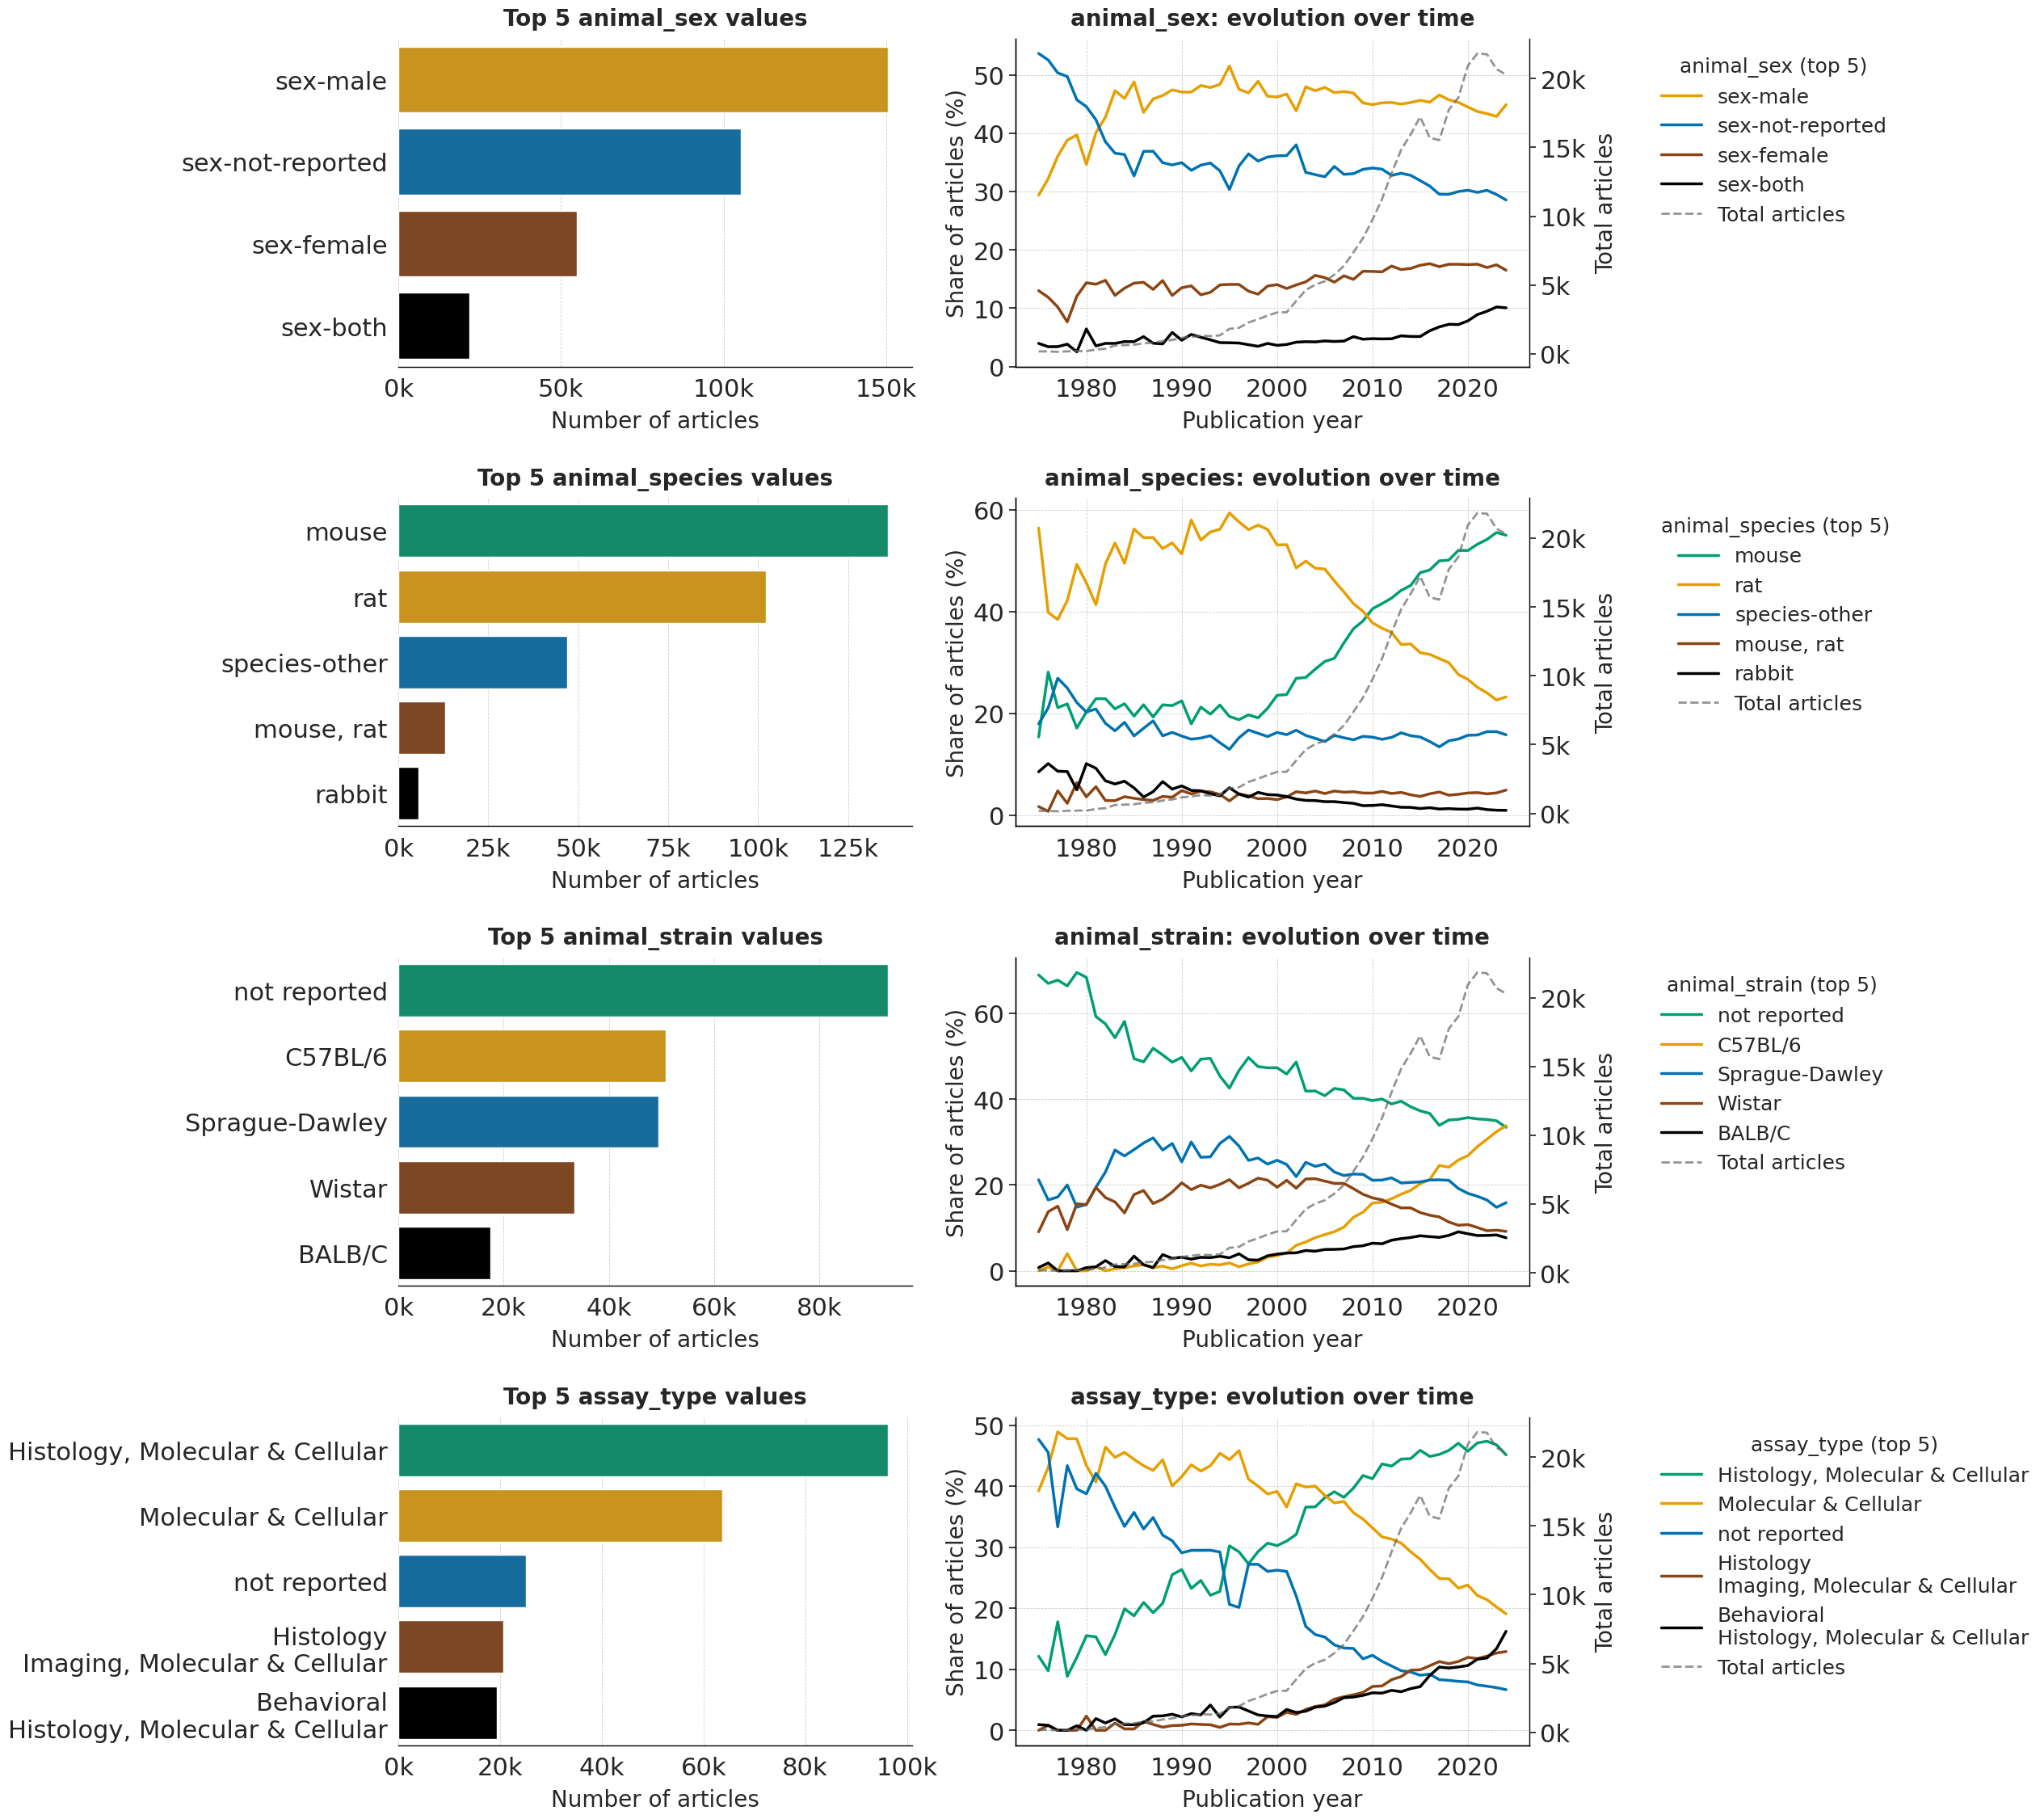

In [277]:
cols_to_plot = ['animal_sex', 'animal_species', 'animal_strain', 'assay_type']

visualize_columns_nature(
    dataset_fulltext,
    cols_to_plot,
    exclude_years=[2025],
    top_n=5,
    save_path = "viz/animal_studies_metadata.pdf"
)


In [232]:
def visualize_trends_nature_style(
    df,
    columns,
    year_col="year",
    top_n=10,
    min_year_count=25,
    exclude_years=None,
    max_cols=4,
    save_path=None
):
    """
    Nature-style visualization: trend-over-time plots for multiple categorical columns.

    Each column shows:
      - Top N categories by total frequency
      - % of articles over time (lines)
      - Total article volume (dashed grey line)
    Arranged in a grid (max 4 per row).

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe with categorical columns and a year column.
    columns : list
        List of categorical columns to visualize.
    year_col : str
        Column name for publication year.
    top_n : int
        Number of top categories per variable to display.
    min_year_count : int
        Minimum number of papers required for a year to be included.
    exclude_years : list
        Optional list of years to exclude.
    max_cols : int
        Maximum number of subplots per row.
    save_path : str
        Optional path to save figure.
    """

    colorblind10 = [
        "#000000",  # black
        "#009E73",  # bluish green
        "#CC79A7",  # reddish purple
        "#8B4513",  # brown
        "#0072B2",  # blue
        "#E69F00",  # orange
        "#009E73",  # bluish green
        "#F0E442",  # yellow
        "#D55E00",  # vermillion red
        "#CC79A7",  # reddish purple
        "#56B4E9",  # light blue
        "#999999",  # grey
        
    ]


    # ---- Style setup ----
    sns.set_theme(style="whitegrid", font_scale=1.4)
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "DejaVu Sans"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "black",
        "axes.linewidth": 1.0,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "axes.labelsize": 18,
        "axes.titlesize": 16,
        "xtick.labelsize": 17,
        "ytick.labelsize": 17,
        "legend.fontsize": 14,
        "legend.title_fontsize": 17,
    })

    # --- Filter valid years ---
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    if exclude_years is not None:
        df = df[~df[year_col].isin(exclude_years)]

    year_counts = df[year_col].value_counts()
    valid_years = year_counts[year_counts >= min_year_count].index
    df = df[df[year_col].isin(valid_years)].sort_values(by=year_col)

    total_per_year = df.groupby(year_col).size()

    # --- Determine grid ---
    n_cols = min(max_cols, len(columns))
    n_rows = math.ceil(len(columns) / n_cols)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(6 * n_cols, 5 * n_rows),
        sharex=True,
        gridspec_kw={"wspace": 0.25, "hspace": 0.4}
    )
    axes = axes.flatten() if len(columns) > 1 else [axes]

    for i, col in enumerate(columns):
        ax = axes[i]
    
        # Identify top N categories for this column
        top_values = df[col].value_counts().head(top_n).index
        subset = df[df[col].isin(top_values)]
    
        # Prepare trend data
        trend_data = subset.groupby([year_col, col]).size().unstack(fill_value=0)
        trend_pct = trend_data.div(trend_data.sum(axis=1), axis=0) * 100
    
        # Colors for top categories
        color_map = dict(zip(trend_pct.columns, colorblind10[:len(trend_pct.columns)]))
        line_colors = [color_map[v] for v in trend_pct.columns]
    
        # Plot % of articles
        trend_pct.plot(ax=ax, linewidth=2.2, color=line_colors)
        ax.set_ylim(0, 100)
        # Add total article volume (secondary axis)
        ax_twin = ax.twinx()
        total_per_year.plot(
            ax=ax_twin, color="#666666", linestyle="--", linewidth=2, alpha=0.7,
            label="Total articles"
        )
        ax_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
        ax_twin.grid(False)
    
        # --- Axis label logic ---
        row_idx = i // n_cols
        col_idx = i % n_cols
    
        # Leftmost plots → left y-label
        if col_idx == 0:
            ax.set_ylabel("% of articles")
        else:
            ax.set_ylabel("")
            #ax.tick_params(labelleft=False)
    
        # Rightmost plots → right y-label
        if col_idx == n_cols - 1 or i == len(columns) - 1:
            ax_twin.set_ylabel("Total articles")
        else:
            ax_twin.set_ylabel("")
            #ax_twin.tick_params(labelright=False)
    
        # X-axis
        ax.set_xlabel("Year")
    
        # Title and styling
        ax.set_title(f"{col} – share over time", pad=10, weight="bold")
        sns.despine(ax=ax, left=False, right=False)
    
        # Legend
        handles, labels = ax.get_legend_handles_labels()
        handles2, labels2 = ax_twin.get_legend_handles_labels()
        ax.legend(
            handles + handles2,
            labels + labels2,
            loc="center left",
            frameon=False,
        )

    # Hide unused axes (if any)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.subplots_adjust(left=0.07, right=0.94, top=0.93, bottom=0.07)
    fig.patch.set_facecolor("white")

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300, facecolor="white")

    plt.show()

In [233]:
dataset_fulltext["sample_size"].replace("sample-size-not-performed", "sample-size-not-reported", inplace=True)


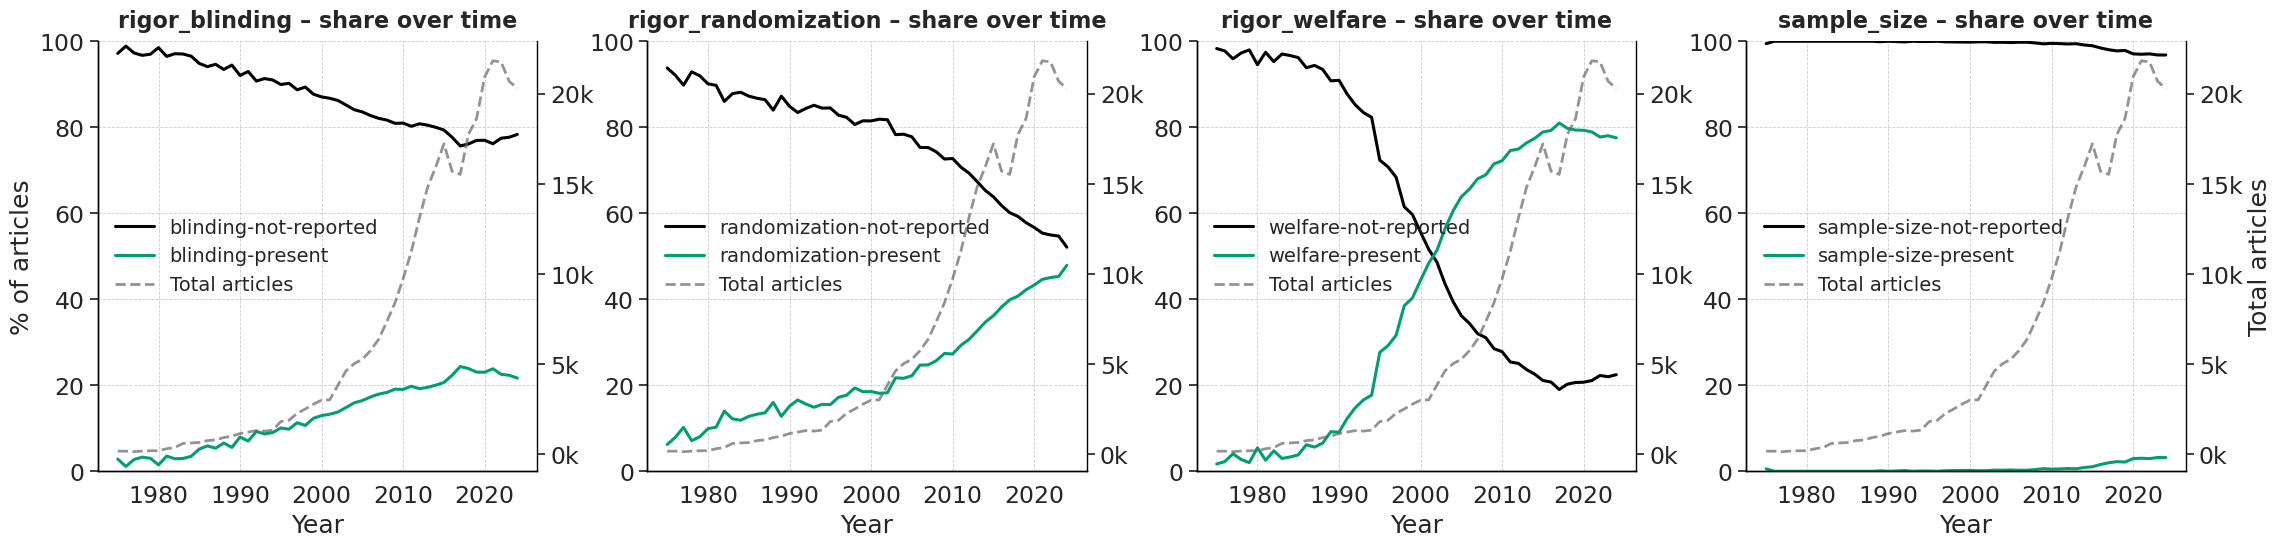

In [234]:
cols_to_plot = ['rigor_blinding', 'rigor_randomization', 'rigor_welfare', 'sample_size']
visualize_trends_nature_style(
    dataset_fulltext,
    cols_to_plot,
    exclude_years=[2025],
    save_path = "viz/animal_studies_rigor.pdf"
)


In [260]:
def visualize_selected_value_trends(
    df,
    columns,
    values,
    year_col="year",
    min_year_count=25,
    exclude_years=None,
    save_path=None
):
    """
    Nature-style visualization of trends for specific values from multiple columns.

    Each line represents the share of articles over time
    for one (column, value) pair, e.g. ('animal_species', 'mouse').

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    columns : list of str
        Categorical columns to visualize.
    values : list of str
        Specific values (one per column).
    year_col : str
        Column name for publication year.
    min_year_count : int
        Minimum number of papers required per year to be included.
    exclude_years : list
        Optional list of years to exclude.
    save_path : str
        Optional path to save the figure.
    """

    assert len(columns) == len(values), "`columns` and `values` must have the same length."

    colorblind10 = [
        "#000000", "#0072B2", "#E69F00", "#009E73",
        "#F0E442", "#D55E00", "#CC79A7", "#56B4E9",
        "#8B4513", "#999999"
    ]

    # --- Style ---
    sns.set_theme(style="whitegrid", font_scale=1.5)
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "DejaVu Sans"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "black",
        "axes.linewidth": 1.0,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "axes.labelsize": 18,
        "axes.titlesize": 20,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 15,
        "legend.title_fontsize": 15,
    })

    # --- Prepare dataframe ---
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    if exclude_years is not None:
        df = df[~df[year_col].isin(exclude_years)]

    year_counts = df[year_col].value_counts()
    valid_years = year_counts[year_counts >= min_year_count].index
    df = df[df[year_col].isin(valid_years)].sort_values(by=year_col)

    total_per_year = df.groupby(year_col).size()

    # --- Plot setup ---
    fig, ax = plt.subplots(figsize=(10, 6))

    for i, (col, val) in enumerate(zip(columns, values)):
        subset = df[df[col] == val]
        yearly_counts = subset.groupby(year_col).size()
        share = (yearly_counts / total_per_year * 100).reindex(total_per_year.index).fillna(0)

        ax.plot(
            share.index,
            share.values,
            label=f"{val}",
            color=colorblind10[i % len(colorblind10)],
            linewidth=2.5
        )

    # --- Total papers (secondary y-axis) ---
    ax_twin = ax.twinx()
    total_per_year.plot(
        ax=ax_twin,
        color="#666666",
        linestyle="--",
        linewidth=2,
        alpha=0.7,
        label="Total articles"
    )

    # --- Styling ---
    ax.set_xlabel("Publication year", labelpad=8)
    ax.set_ylabel("Share of articles (%)")
    ax_twin.set_ylabel("Total articles", labelpad=8)
    ax_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
    ax_twin.grid(False)

    ax.set_title("Trends of selected categories over time", pad=12, weight="bold")
    sns.despine(ax=ax, left=False, right=False)

    # --- Legend outside ---
    handles, labels = ax.get_legend_handles_labels()
    handles2, labels2 = ax_twin.get_legend_handles_labels()
    ax.legend(
        handles + handles2,
        labels + labels2,
        #bbox_to_anchor=(1.15, 1),
        loc="upper left",
        frameon=False,
        #itle="Selected trends"
    )

    plt.subplots_adjust(left=0.08, right=0.78, top=0.93, bottom=0.07)
    fig.patch.set_facecolor("white")

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300, facecolor="white")

    plt.show()

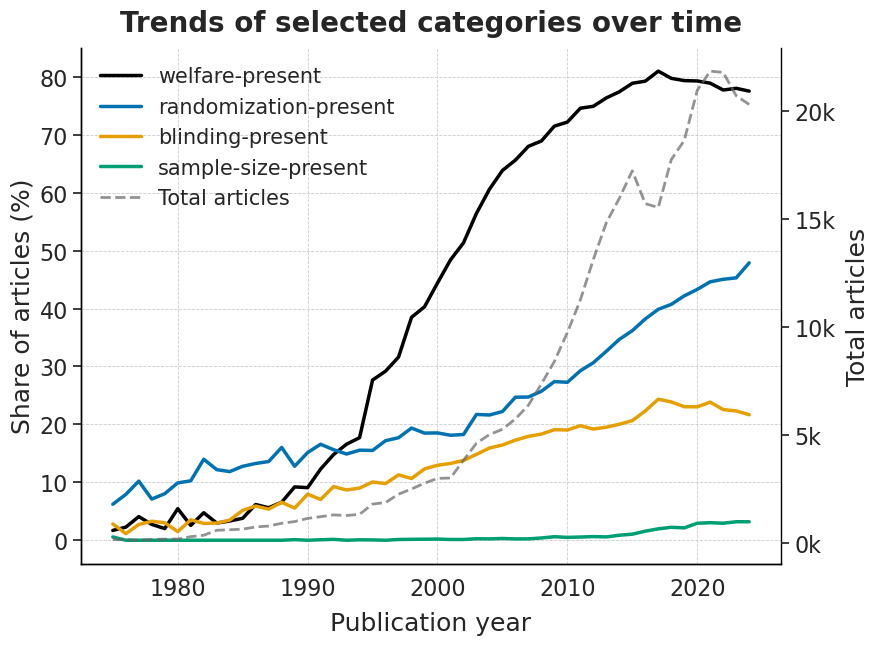

In [264]:
cols_to_plot = ['rigor_welfare',  'rigor_randomization', 'rigor_blinding', 'sample_size']

visualize_selected_value_trends(
    dataset_fulltext,
    columns=cols_to_plot,
    values=["welfare-present",  "randomization-present", "blinding-present",  "sample-size-present"],
    exclude_years=[2025],
    min_year_count=25,
    save_path = "viz/animal_studies_rigor_single.pdf"
)

In [244]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

def visualize_bars_and_trend(
    df,
    columns,
    year_col="year",
    top_n=10,
    min_year_count=100,
    exclude_years=None,
    save_path=None
):
    """
    Nature-style figure with two bar plots and one trend plot in a single row.

    - First column → independent bar chart.
    - Second column → bar chart (shares colors with trend plot).
    - Third column → trend line plot (% over time).
    - Long category labels automatically wrapped after the 5th word.
    """

    assert len(columns) == 3, "Please provide exactly 3 columns."

    colorblind10 = [
        "#000000", "#009E73", "#CC79A7", "#8B4513",
        "#0072B2", "#E69F00", "#F0E442", "#D55E00",
        "#56B4E9", "#999999"
    ]

    # ---- Style setup ----
    sns.set_theme(style="whitegrid", font_scale=1.4)
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "DejaVu Sans"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "black",
        "axes.linewidth": 1.0,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "axes.labelsize": 22,
        "axes.titlesize": 20,
        "xtick.labelsize": 21,
        "ytick.labelsize": 21,
        "legend.fontsize": 18,
        "legend.title_fontsize": 21,
    })

    # --- Helper: wrap long labels after 5 words ---
    def wrap_label(label, max_words=3):
        if isinstance(label, str):
            words = label.split(" ")
            if len(words) > max_words:
                return " ".join(words[:max_words]) + "\n" + " ".join(words[max_words:])
        return label

    # --- Clean and filter ---
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    if exclude_years is not None:
        df = df[~df[year_col].isin(exclude_years)]

    year_counts = df[year_col].value_counts()
    valid_years = year_counts[year_counts >= min_year_count].index
    df = df[df[year_col].isin(valid_years)]

    total_per_year = df.groupby(year_col).size()

    # Consistent color map for 2nd & 3rd columns
    shared_col = columns[1]
    trend_col = columns[2]

    top_shared_values = df[shared_col].value_counts().head(top_n).index
    consistent_color_map = dict(zip(top_shared_values, colorblind10[:len(top_shared_values)]))

    # --- Setup figure ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={"wspace": 0.35})

    # === BAR 1 (independent colors) ===
    col = columns[0]
    ax = axes[0]
    top_values = df[col].value_counts().head(top_n).sort_values(ascending=False)
    sns.barplot(
        y=[wrap_label(v) for v in top_values.index],  # 🟢 wrapped labels
        x=top_values.values,
        ax=ax,
        palette=colorblind10[:len(top_values)]
    )
    ax.set_title(f"Top {top_n} {col}", pad=10, weight="bold")
    ax.set_xlabel("Number of articles")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
    sns.despine(ax=ax, left=True)

    # === BAR 2 (shares colors with trend plot) ===
    col = shared_col
    ax = axes[1]
    top_values = df[col].value_counts().head(top_n).sort_values(ascending=False)
    bar_colors = [consistent_color_map.get(v, "#BBBBBB") for v in top_values.index]

    sns.barplot(
        y=[wrap_label(v) for v in top_values.index],  # 🟢 wrapped labels
        x=top_values.values,
        ax=ax,
        palette=bar_colors
    )
    ax.set_title(f"Top {top_n} {col}", pad=10, weight="bold")
    ax.set_xlabel("Number of articles")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
    sns.despine(ax=ax, left=True)

    # === TREND (3rd col, shares colors with 2nd) ===
    ax = axes[2]
    
    # --- Filter to top categories only ---
    top_cats = top_shared_values
    subset = df[df[trend_col].isin(top_cats)]
    
    # --- Compute total papers per year *within the subset* ---
    year_totals = subset.groupby(year_col).size()
    
    # 🟢 Keep only years with enough papers (within subset)
    valid_years = year_totals[year_totals >= min_year_count].index
    subset = subset[subset[year_col].isin(valid_years)]
    year_totals = year_totals[year_totals.index.isin(valid_years)]
    
    # --- Compute trend data ---
    trend_data = subset.groupby([year_col, trend_col]).size().unstack(fill_value=0)
    trend_data = trend_data[[cat for cat in top_values.index if cat in trend_data.columns]]
    trend_pct = trend_data.div(trend_data.sum(axis=1), axis=0) * 100
    
    # 🟢 Ensure we only plot valid years, sorted chronologically
    trend_pct = trend_pct.loc[sorted(valid_years)]
    year_totals = year_totals.loc[sorted(valid_years)]
    
    # 🟢 Define colors here (AFTER we know trend_pct columns)
    line_colors = [consistent_color_map.get(v, "#BBBBBB") for v in trend_pct.columns]
    
    # --- Plot ---
    trend_pct.plot(ax=ax, linewidth=2.2, color=line_colors)

    # Total articles (secondary axis)
    ax_twin = ax.twinx()
    year_totals.plot(   # 🟢 use the filtered subset, not total_per_year
        ax=ax_twin,
        color="#666666",
        linestyle="--",
        linewidth=2,
        alpha=0.7,
        label="Total articles"
    )

    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax_twin.grid(False)
    ax_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))

    ax.set_xlabel("Year")
    ax.set_ylabel("% of articles")
    ax_twin.set_ylabel("Total articles")
    ax.set_title(f"{trend_col} – share over time", pad=10, weight="bold")

    sns.despine(ax=ax, left=False, right=False)

    # Legend
    handles, labels = ax.get_legend_handles_labels()
    handles2, labels2 = ax_twin.get_legend_handles_labels()
    ax.legend(
        handles + handles2,
        labels + labels2,
        bbox_to_anchor=(1.25, 1),  # 🟢 move outside to the right
        loc="upper left",
        frameon=False,
        #title=f"Top {top_n} {trend_col}",
    )

    # --- Final layout ---
    plt.subplots_adjust(left=0.07, right=0.95, top=0.90, bottom=0.10)
    fig.patch.set_facecolor("white")

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300, facecolor="white")

    plt.show()


/sctmp/sdonev/ipykernel_1405543/962381800.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/sctmp/sdonev/ipykernel_1405543/962381800.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


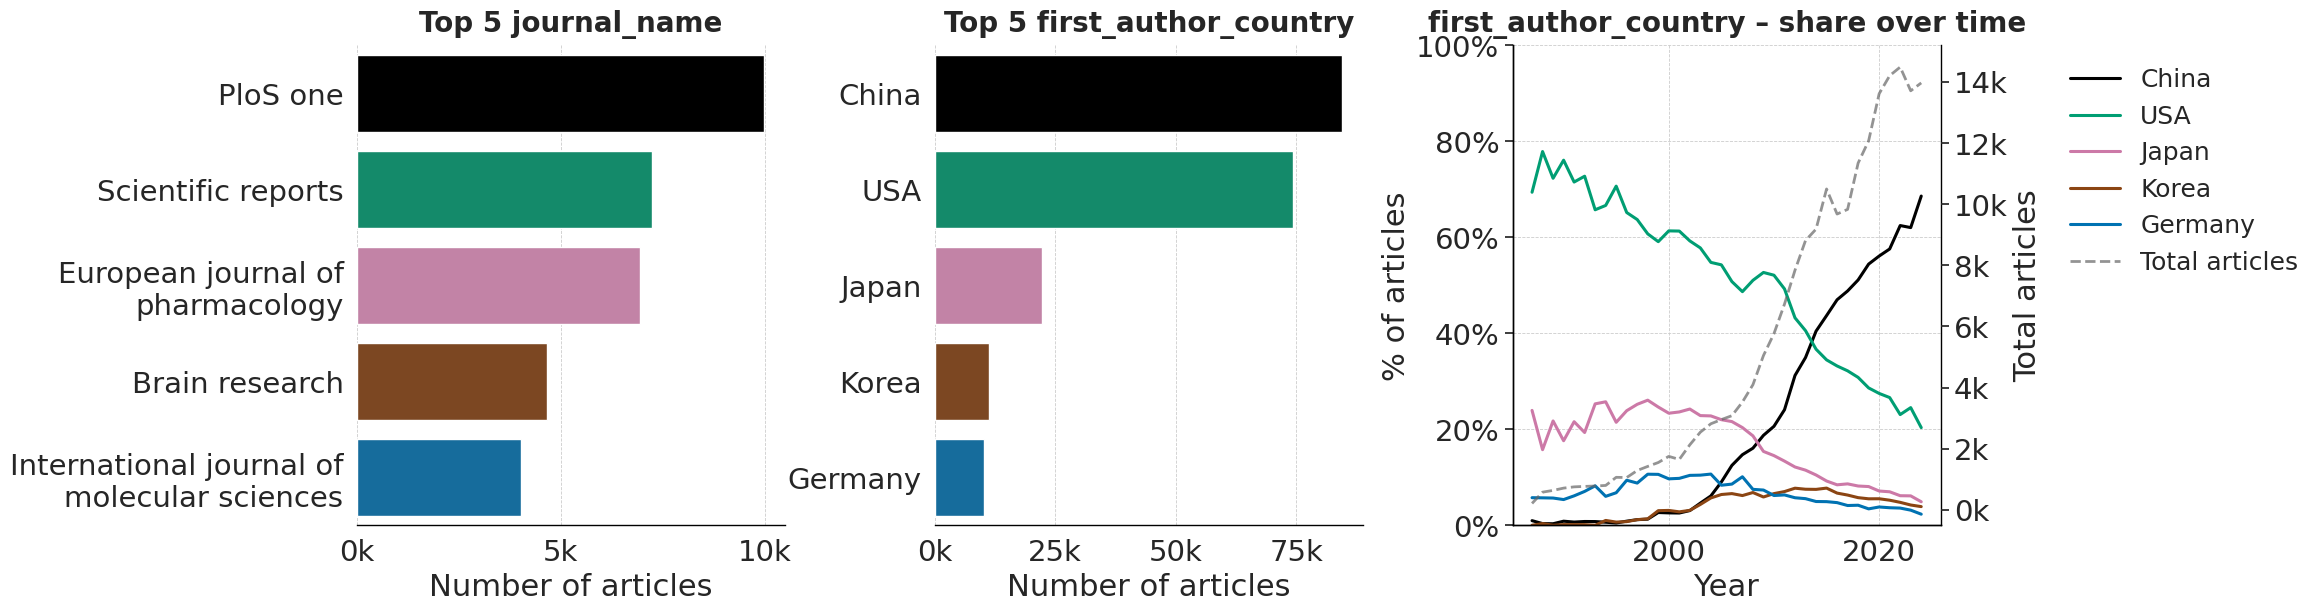

In [245]:
visualize_bars_and_trend(
    dataset_fulltext,
    columns=["journal_name", "first_author_country", "first_author_country"],
    year_col="year",
    exclude_years=[2025],
    top_n=5,
    save_path = "viz/animal_studies_journal_country.pdf"
)

In [171]:
df = dataset_fulltext.copy()
trend_col = "first_author_country"
year_col="year"
top_shared_values = df[trend_col].value_counts().head(10).index
min_year_count = 25

top_cats = top_shared_values
subset = df[df[trend_col].isin(top_cats)]

# --- Compute total papers per year ---
year_totals = subset.groupby(year_col).size()

# 🟢 Keep only years with enough papers
valid_years = year_totals[year_totals >= min_year_count].index
subset = subset[subset[year_col].isin(valid_years)]
year_totals = year_totals[year_totals.index.isin(valid_years)]

# --- Compute trend data ---
trend_data = subset.groupby([year_col, trend_col]).size().unstack(fill_value=0)
trend_pct = trend_data.div(trend_data.sum(axis=1), axis=0) * 100

In [187]:
test_df = dataset_fulltext[['PMID','year','first_author_country']]
test_df[test_df['year']==1980].first_author_country.unique()

array(['unlabeled'], dtype=object)